<a href="https://colab.research.google.com/github/Anaswaraks/Time-series-forecasting-on-Apple-stock/blob/main/Time_Series_Forecasting_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

In [ ]:
ticker = 'AAPL'
data = yf.download(ticker, start="2020-01-01", end="2025-01-01")
data = data['Close'].values.reshape(-1, 1)

# Normalizing the Data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

#Preparing the Data for Time Series

def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Splitting the Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

/tmp/ipykernel_10141/723860317.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
#Building the RNN Model

model = Sequential()
model.add(SimpleRNN(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(SimpleRNN(units=50, return_sequences=False))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#Training the Model
model.fit(X_train, y_train, epochs=20, batch_size=64)

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0831
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0094
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0021
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0012
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 8.7680e-04
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 7.0954e-04
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 6.1612e-04
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 5.9437e-04
Epoch 9/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 5.6417e-04
Epoch 10/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 4.9083e-04
Epoch 11/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 4.2791e-04
Epoch 12/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 4.1801e-04
Epoch 13/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 3.8715e-04
Epoch 14/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 3.9664e-04
Epoch 15/20
15/15 ━━━━━━━━━━━━━

In [ ]:
#Evaluating the model

y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))

mse = mean_squared_error(y_test_unscaled, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_unscaled, predictions)

print(f"Unscaled Mean Squared Error (MSE): {mse}")
print(f"Unscaled Root Mean Squared Error (RMSE): {rmse}")
print(f"Unscaled Mean Absolute Error (MAE): {mae}")

Unscaled Mean Squared Error (MSE): 60.5275546544086
Unscaled Root Mean Squared Error (RMSE): 7.77994567168747
Unscaled Mean Absolute Error (MAE): 6.175806617736816


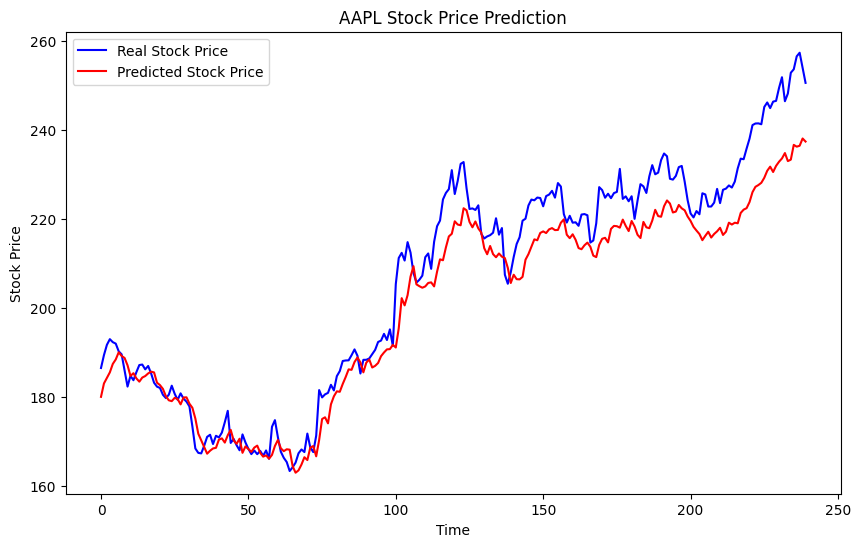

In [ ]:
#Visualizing the Results

plt.figure(figsize=(10,6))
plt.plot(scaler.inverse_transform(y_test.reshape(-1, 1)), color='blue', label='Real Stock Price')
plt.plot(predictions, color='red', label='Predicted Stock Price')
plt.title(f'{ticker} Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()